In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences.base import TipVoltageSweep, Sequence, RFPowerSweep
from edes.experiments.devices.base import Instrument
from edes.utils.file_handling import load_latest_data
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
from edes.utils.utils import beep_VS
# beep_VS()

In [3]:
exp = Experiment('3layer_trapping_062226')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> ERROR connecting to Agilent34461A at USB0::2391::7175::MY53200916::0::INSTR: No device found.
>>> Connected to ARTIQ Zotino.
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> Connected to KEITHLEY INSTRUMENTS INC.,MODEL 2100,1,01.07-01-01
>>> ERROR connecting to SiglentSPD3303X_E at TCPIP::192.168.169.101::INSTR: [Errno 104] Connection reset by peer
>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> Connected to Valon at ASRL/dev/ttyUSB0::INSTR with frequency 1473950000.0 Hz and power 0 dBm.


In [4]:
exp.list_devices()

['Agilent', 'DAC', 'FEtip_PSU', 'Keithley', 'LNA_PSU', 'SSA', 'Valon']

In [25]:
exp.FEtip_PSU.ramp_down(0)

In [53]:
tip_Vsweep = TipVoltageSweep(saving_dir=exp.saving_dir, 
                             V_start=1300, V_stop=2200, V_step=100, R=100e6, 
                             N_avg=8, t_PSU_settle=2, t_meas_delay=0.2, 
                             FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Keithley)

In [66]:
file = tip_Vsweep.run_save()

100%|██████████| 9/9 [00:34<00:00,  3.82s/it]


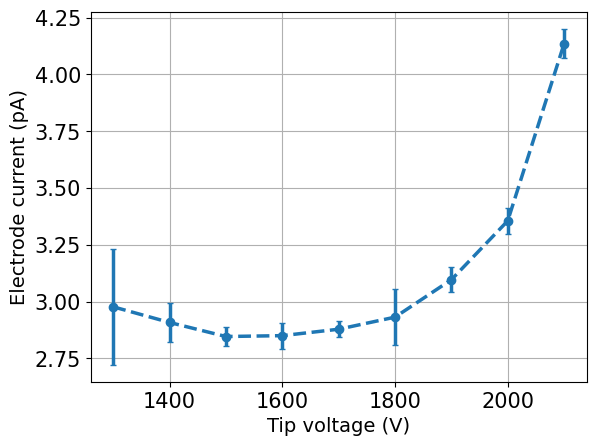

In [67]:
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (pA)')
# plt.yscale('log')

In [113]:
exp.Valon.set_frequency(1.47395e9)
exp.Valon.set_power(0)
exp.Valon.output_off()

In [85]:
exp.DAC.set_multipoles(Ex=-0.1, U2=-0.4)

RID: 9826
voltages loaded


In [111]:
exp.FEtip_PSU.ramp_up(1900)

In [114]:
exp.FEtip_PSU.ramp_down(0)